<h1 style="color: green;">Home task</h1>

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


## Load the Data

In [10]:
def load_dataset():
    fn = '/Users/user/Desktop/Camp2025/lesson_25/data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    fn = '/Users/user/Desktop/Camp2025/lesson_25/data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
X_train, Y_train, X_test, Y_test, classes = load_dataset()

print ('train_data.shape=', X_train.shape)
print ('train_labels.shape=',  Y_train.shape)
print ('test_data.shape=', X_test.shape)
print ('test_labels.shape=', Y_test.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


## Review the data

In [11]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

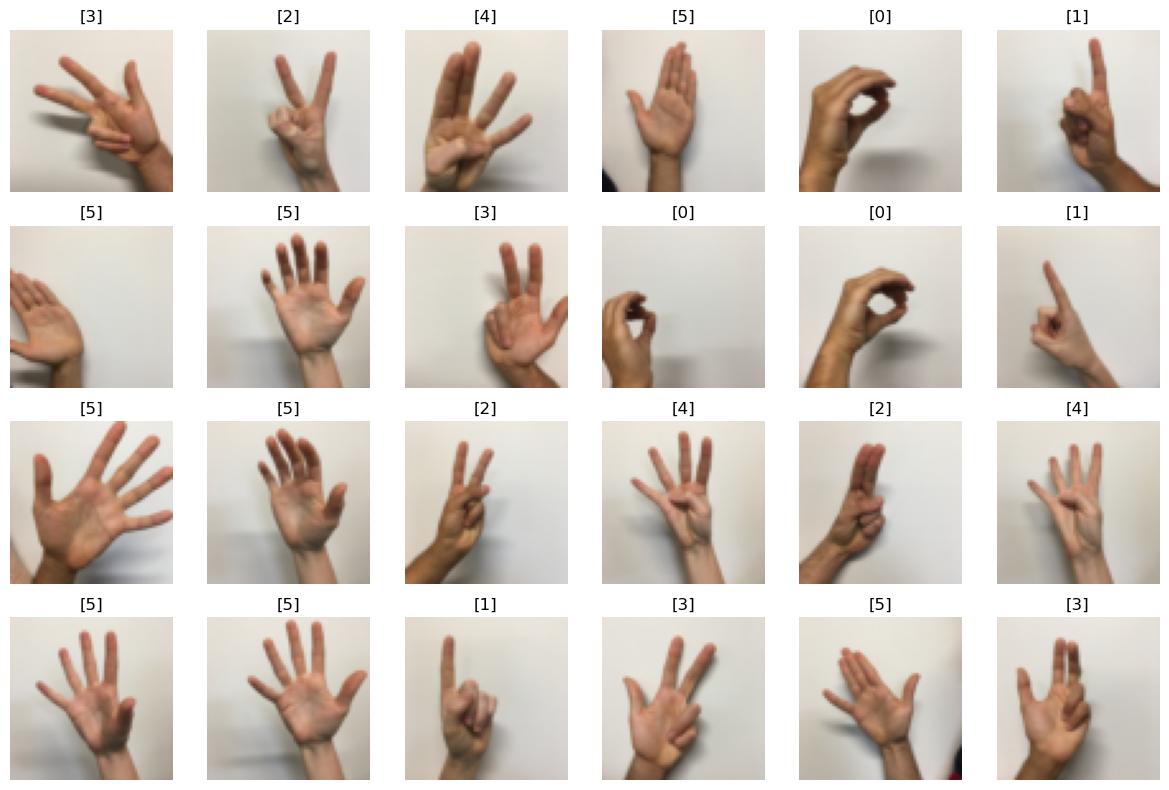

In [12]:
nClasses = len(classes)
plt.figure(figsize=(12,8))
display_samples_in_grid(X_train, n_rows=4, n_cols=6, y=Y_train.T)
plt.tight_layout(h_pad=1, w_pad=1)


## Process the data

In [13]:
X_train_original = X_train.copy()
Y_train_original = Y_train.copy()

dimData = np.prod(X_train.shape[1:])
X_train = X_train.reshape(X_train.shape[0], dimData)
X_test = X_test.reshape(X_test.shape[0], dimData)

In [14]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [15]:
Y_train_one_hot = to_categorical(Y_train[0])
Y_test_one_hot = to_categorical(Y_test[0])
 
print('Original label [0] : ', Y_train[0])
print('After conversion to categorical ( one-hot ) : ', Y_train_one_hot[0])

Original label [0] :  [5 0 2 ... 2 4 5]
After conversion to categorical ( one-hot ) :  [0. 0. 0. 0. 0. 1.]


In [16]:
def Graphic(history):
    plt.figure(figsize=[8, 6])
    plt.plot(history.history['loss'], 'r', linewidth=3.0)
    plt.plot(history.history['val_loss'], 'b', linewidth=3.0)
    plt.legend(['Training loss', 'Testing Loss'], fontsize=18)
    plt.xlabel('Epochs ', fontsize=16)
    plt.ylabel('Loss', fontsize=16)
    plt.title('Loss Curves', fontsize=16)

    plt.figure(figsize=[8, 6])
    plt.plot(history.history['accuracy'], 'r', linewidth=3.0)
    plt.plot(history.history['val_accuracy'], 'b', linewidth=3.0)
    plt.legend(['Training Accuracy', 'Testing Accuracy'], fontsize=18)
    plt.xlabel('Epochs ', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.title('Accuracy Curves', fontsize=16)

## Create the model

In [17]:
from keras.models import Sequential
from keras.layers import Dense
 
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(dimData,)))
model.add(Dense(512, activation='relu'))
model.add(Dense(nClasses, activation='softmax'))

/Library/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.1329 - loss: 14.6053 - val_accuracy: 0.1667 - val_loss: 6.8302
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.1770 - loss: 5.0145 - val_accuracy: 0.1667 - val_loss: 2.5217
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.1725 - loss: 2.2767 - val_accuracy: 0.2000 - val_loss: 2.1282
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.2110 - loss: 2.0057 - val_accuracy: 0.1833 - val_loss: 1.8264
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3145 - loss: 1.8002 - val_accuracy: 0.2250 - val_loss: 1.7506
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3044 - loss: 1.7194 - val_accuracy: 0.2917 - val_loss: 1.6916
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.3215 - loss: 1.6819 - val_accuracy: 0.2667 - val_loss: 1.7445
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3180 - loss: 1.6771 - val_accuracy: 0.3167 - val_loss: 1.64

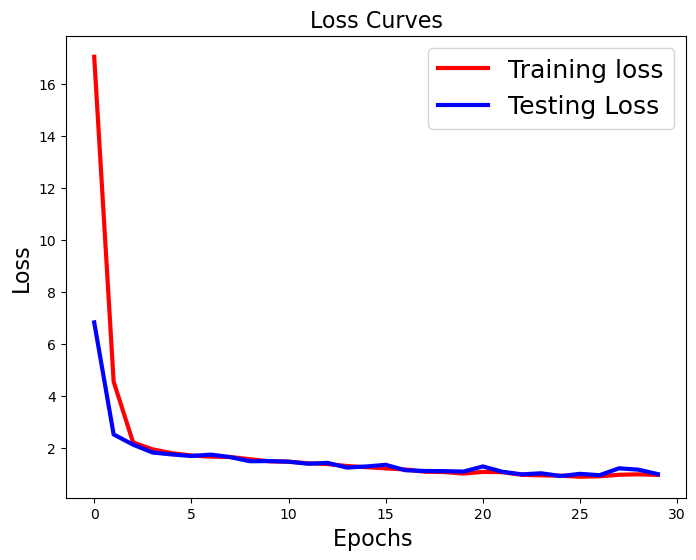

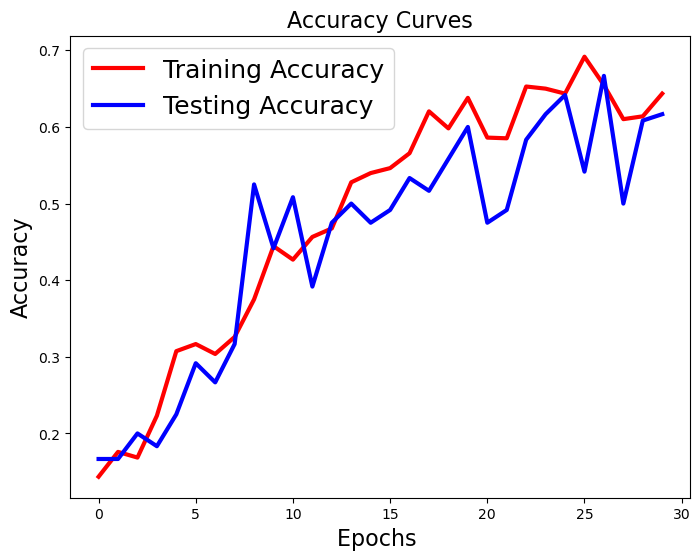

In [18]:
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
import keras

class MyModelReLU(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.flatten = Flatten()
        self.dense1 = Dense(512, activation="relu")
        self.dense2 = Dense(512, activation="relu")
        self.classify = Dense(nClasses, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.classify(x)

model = MyModelReLU(6)
model.compile(optimizer=keras.optimizers.Adam(1e-3), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(X_train, Y_train_one_hot, batch_size=128, epochs=30,
                    validation_data=(X_test, Y_test_one_hot), verbose=1)
Graphic(history)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.1821 - loss: 1.8097 - val_accuracy: 0.1667 - val_loss: 1.8032
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.2044 - loss: 1.7944 - val_accuracy: 0.2917 - val_loss: 1.7487
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3068 - loss: 1.7465 - val_accuracy: 0.2167 - val_loss: 1.6798
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2588 - loss: 1.6866 - val_accuracy: 0.3000 - val_loss: 1.6182
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.3562 - loss: 1.6121 - val_accuracy: 0.4000 - val_loss: 1.4804
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3978 - loss: 1.4769 - val_accuracy: 0.4333 - val_loss: 1.3684
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.4261 - loss: 1.3849 - val_accuracy: 0.5333 - val_loss: 1.2453
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5096 - loss: 1.2739 - val_accuracy: 0.3667 - val_loss: 1.4505


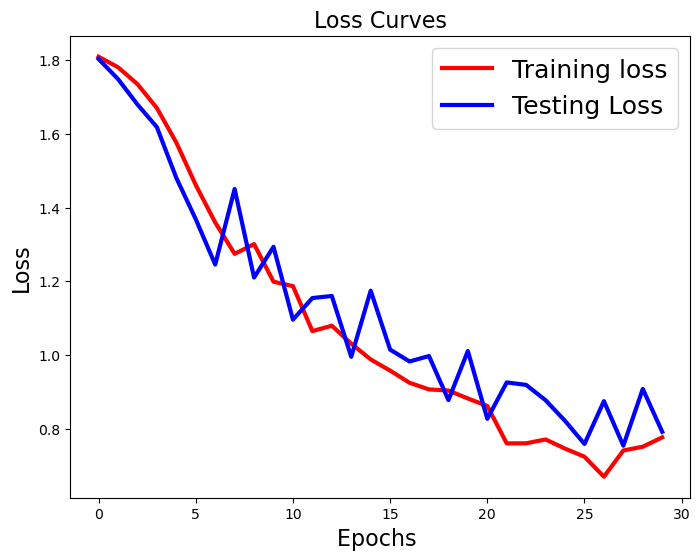

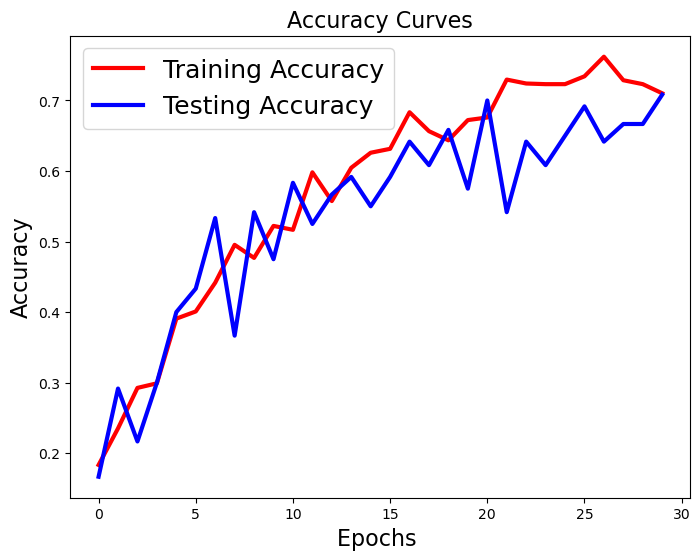

In [19]:
from tensorflow.keras.layers import Flatten

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

class MyModelTanh(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.flatten = Flatten()
        self.dense1 = Dense(512, activation="tanh")
        self.dense2 = Dense(512, activation="tanh")
        self.classify = Dense(nClasses, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.classify(x)

model = MyModelTanh(6)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(X_train, Y_train_one_hot,
                    batch_size=128, epochs=30, verbose=1,
                    validation_data=(X_test, Y_test_one_hot))
Graphic(history)



Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.1714 - loss: 1.9229 - val_accuracy: 0.1667 - val_loss: 1.8493
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.1707 - loss: 1.8237 - val_accuracy: 0.1667 - val_loss: 1.8049
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.1609 - loss: 1.8140 - val_accuracy: 0.1667 - val_loss: 1.8021
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.1544 - loss: 1.8084 - val_accuracy: 0.1667 - val_loss: 1.7962
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.1707 - loss: 1.8003 - val_accuracy: 0.1667 - val_loss: 1.8102
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.1373 - loss: 1.8165 - val_accuracy: 0.1667 - val_loss: 1.7993
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.1767 - loss: 1.8143 - val_accuracy: 0.1667 - val_loss: 1.8360
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.1686 - loss: 1.8202 - val_accuracy: 0.1667 - val_loss: 1.8090


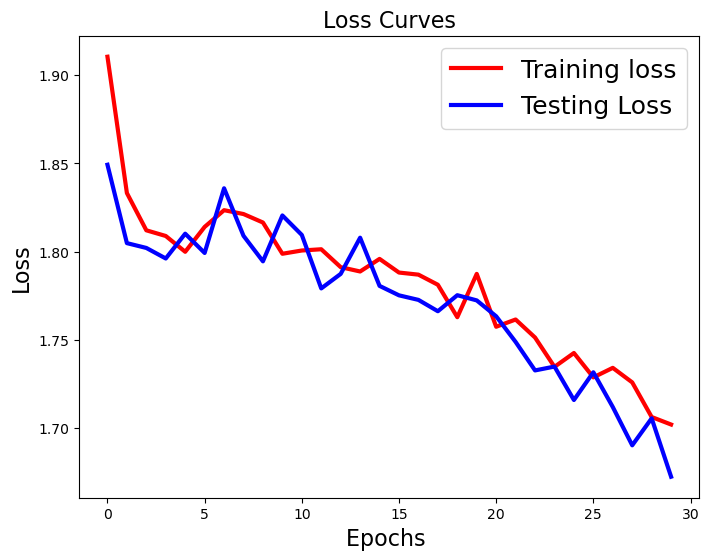

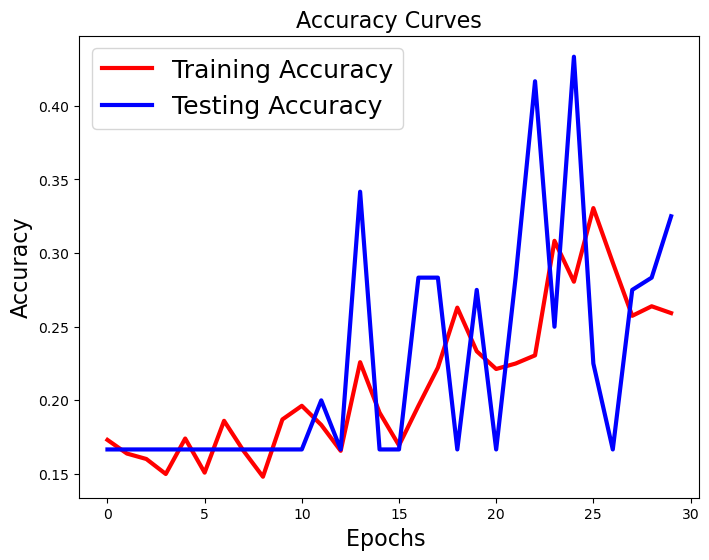

In [20]:
class MyModelSigmoid(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.flatten = Flatten()
        self.dense1 = Dense(512, activation="sigmoid")
        self.dense2 = Dense(512, activation="sigmoid")
        self.classify = Dense(nClasses, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.classify(x)

model = MyModelSigmoid(6)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, Y_train_one_hot, batch_size=128, epochs=30,
                    validation_data=(X_test, Y_test_one_hot), verbose=1)
Graphic(history)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.1638 - loss: 1.7941 - val_accuracy: 0.1667 - val_loss: 1.7901
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.1584 - loss: 1.7936 - val_accuracy: 0.1667 - val_loss: 1.7891
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.1918 - loss: 1.7913 - val_accuracy: 0.2250 - val_loss: 1.7835
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.1691 - loss: 1.7886 - val_accuracy: 0.1750 - val_loss: 1.7773
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.2057 - loss: 1.7788 - val_accuracy: 0.3667 - val_loss: 1.7644
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.2802 - loss: 1.7648 - val_accuracy: 0.3667 - val_loss: 1.7427
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.2855 - loss: 1.7519 - val_accuracy: 0.2417 - val_loss: 1.7218
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.2874 - loss: 1.7270 - val_accuracy: 0.4083 - val_loss: 1.6743

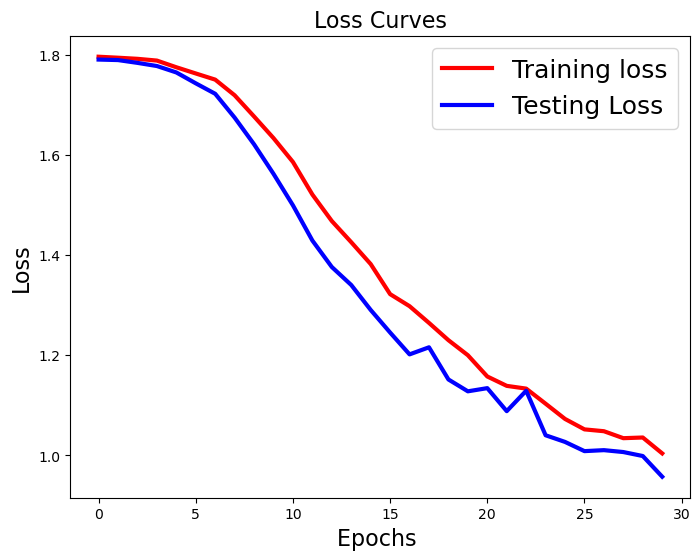

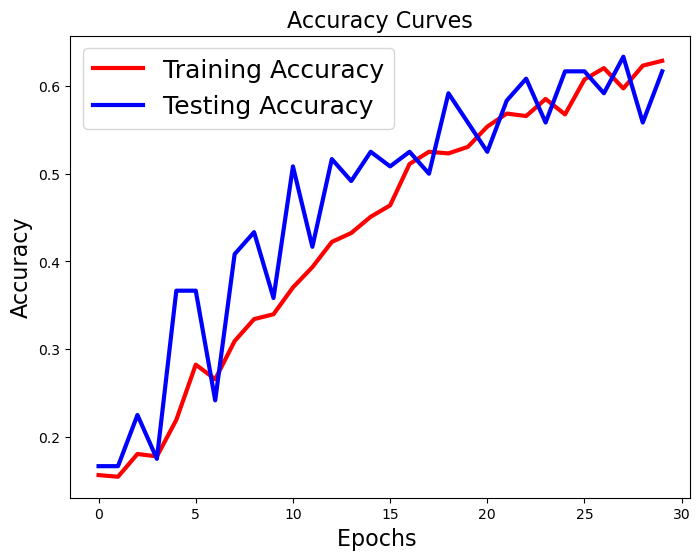

In [25]:
class MyModelDropout(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.flatten = Flatten()
        self.dense1 = Dense(512, activation="relu")
        self.dropout1 = Dropout(0.3)
        self.dense2 = Dense(512, activation="relu")
        self.dropout2 = Dropout(0.3)
        self.classify = Dense(nClasses, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.dense1(x)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        return self.classify(x)

model = MyModelDropout(6)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, Y_train_one_hot, batch_size=128, epochs=30,
                    validation_data=(X_test, Y_test_one_hot), verbose=1)
Graphic(history)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - accuracy: 0.1630 - loss: 1.7953 - val_accuracy: 0.1667 - val_loss: 1.7927
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.1634 - loss: 1.7947 - val_accuracy: 0.1667 - val_loss: 1.7911
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.1560 - loss: 1.7938 - val_accuracy: 0.1667 - val_loss: 1.7907
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.1568 - loss: 1.7910 - val_accuracy: 0.1667 - val_loss: 1.7897
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.1687 - loss: 1.7901 - val_accuracy: 0.3250 - val_loss: 1.7874
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.2450 - loss: 1.7875 - val_accuracy: 0.1667 - val_loss: 1.7823
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.2237 - loss: 1.7831 - val_accuracy: 0.2333 - val_loss: 1.7636
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.2474 - loss: 1.7613 - val_accuracy: 0.3833 - val_loss:

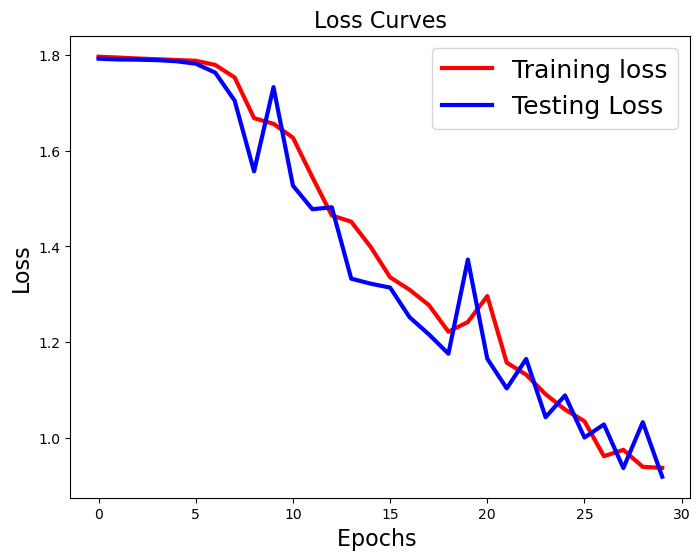

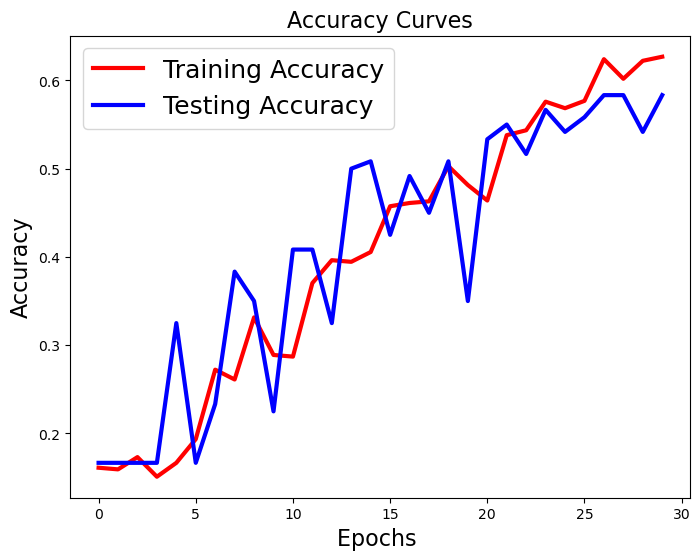

In [24]:
class MyModelDeep(keras.Model):
    def __init__(self, nClasses):
        super().__init__()
        self.flatten = Flatten()
        self.dense1 = Dense(1024, activation="relu")
        self.dense2 = Dense(512, activation="relu")
        self.dense3 = Dense(256, activation="relu")
        self.dense4 = Dense(128, activation="relu")
        self.classify = Dense(nClasses, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classify(x)

model = MyModelDeep(6)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, Y_train_one_hot, batch_size=128, epochs=30,
                    validation_data=(X_test, Y_test_one_hot), verbose=1)
Graphic(history)


### **Model of ReLU activation**

**Pros**
* Fast learning.

* High train/test accuracy


**Cons**
* Risk of overtraining


### **Model of Tanh activation**

**Pros**
* Good for small models


**Cons**
* Slow Ascent


### **Model of Sigmoid activation**

**Pros**
* Can work for small tasks

**Cons**
* Gradient issues
* Significantly lower accuracy


### **Model of ReLU activation + Dropout**

**Pros**
* Reduces overlearning
* Improves generalizationy


**Cons**
* Slightly lower accuracy on train


### **Deep model of ReLU activation** 

**Pros**
* Better agreement with data


**Cons**
* Risk of overtraining without regularization

# Conclusions:
- Sigmoid is the worst choice (gradient decay, almost zero learning).
- ReLU is a good basic activation, learns quickly, but accuracy is lower.
- ReLU + Dropout is an improved version of ReLU, slightly better than it.
- Deep shows high stability and accuracy, almost on par with Tanh.
- Tanh is the best result in this experiment (~70% accuracy on the test), good generalization.